# LeNet-5: Ручная и библиотечная реализация на датасете MNIST

**Предмет:** Теория и практика нейронных сетей

## Содержание
1. Загрузка и ручной препроцессинг данных MNIST
2. Ручная реализация LeNet-5 (NumPy)
3. Библиотечная реализация LeNet-5 (PyTorch)
4. Сравнение результатов и визуализация

## Архитектура LeNet-5 (LeCun et al., 1998)
```
Input  (N, 1, 32, 32)
  C1 : Conv(1→6,  5×5) + tanh → (N,  6, 28, 28)
  S2 : AvgPool(2×2)            → (N,  6, 14, 14)
  C3 : Conv(6→16, 5×5) + tanh → (N, 16, 10, 10)
  S4 : AvgPool(2×2)            → (N, 16,  5,  5)
  C5 : Conv(16→120,5×5)+ tanh → (N,120,  1,  1)  ← фактически FC
  F6 : FC(120→84)  + tanh
  Out: FC(84→10)   → logits
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, struct, gzip, os, urllib.request

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE} | NumPy {np.__version__} | PyTorch {torch.__version__}')

Устройство: cuda | NumPy 2.0.2 | PyTorch 2.10.0+cu128


## 1. Загрузка и ручной препроцессинг данных

In [2]:
MNIST_URLS = {
    'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_images':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}

def download_mnist(data_dir='mnist_data'):
    os.makedirs(data_dir, exist_ok=True)
    paths = {}
    for name, url in MNIST_URLS.items():
        fname = os.path.join(data_dir, url.split('/')[-1])
        if not os.path.exists(fname):
            print(f'Загрузка {name}...')
            urllib.request.urlretrieve(url, fname)
        paths[name] = fname
    return paths

def read_idx_images(path):
    """Ручной парсинг IDX-файла с изображениями (без внешних библиотек)."""
    with gzip.open(path, 'rb') as f:
        magic, n, h, w = struct.unpack('>IIII', f.read(16))
        assert magic == 0x00000803
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, h, w)

def read_idx_labels(path):
    """Ручной парсинг IDX-файла с метками."""
    with gzip.open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        assert magic == 0x00000801
        return np.frombuffer(f.read(), dtype=np.uint8)

paths = download_mnist()
X_train_raw = read_idx_images(paths['train_images'])  # (60000, 28, 28)
y_train      = read_idx_labels(paths['train_labels'])  # (60000,)
X_test_raw   = read_idx_images(paths['test_images'])   # (10000, 28, 28)
y_test       = read_idx_labels(paths['test_labels'])   # (10000,)
print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')

Загрузка train_images...
Загрузка train_labels...
Загрузка test_images...
Загрузка test_labels...
Train: (60000, 28, 28) | Test: (10000, 28, 28)


После препроцессинга: train=(60000, 1, 32, 32), test=(10000, 1, 32, 32)
Диапазон: [0.000, 1.000]


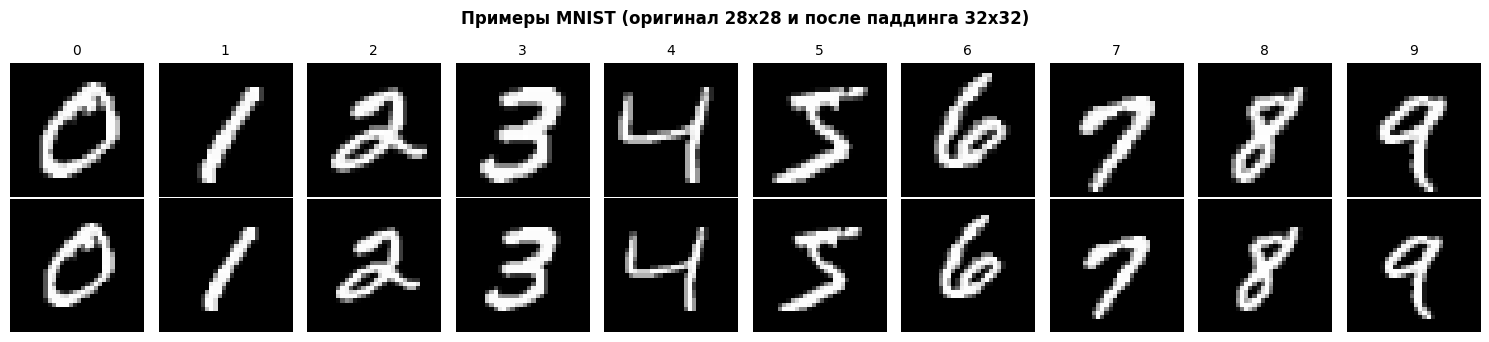

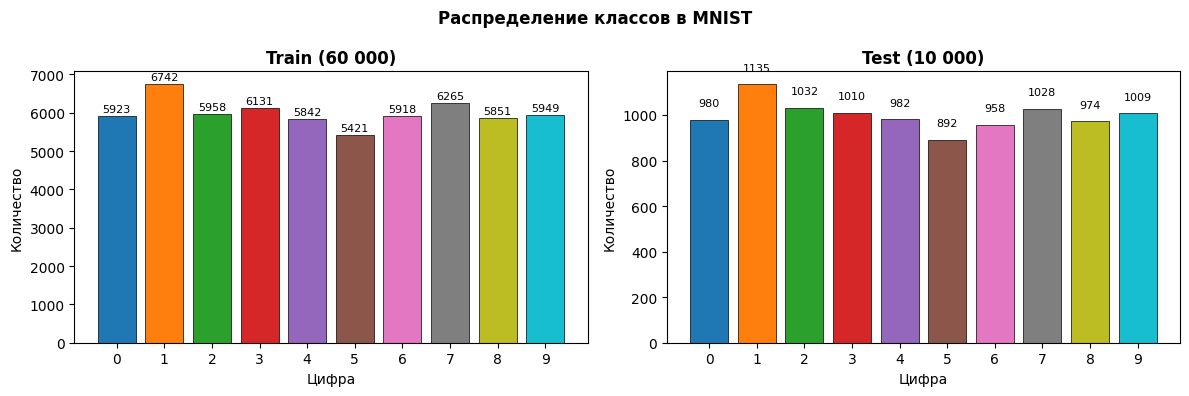

In [3]:
def preprocess(images):
    """
    Ручной препроцессинг:
      1. Zero-padding 28x28 -> 32x32 (LeNet-5 требует 32x32)
      2. Нормализация [0,255] -> [0,1]
      3. Добавление оси канала: (N,32,32) -> (N,1,32,32)
    """
    N = images.shape[0]
    padded = np.zeros((N, 32, 32), dtype=np.float32)
    padded[:, 2:30, 2:30] = images.astype(np.float32) / 255.0
    return padded[:, np.newaxis, :, :]   # channel-first

X_train = preprocess(X_train_raw)   # (60000, 1, 32, 32)
X_test  = preprocess(X_test_raw)    # (10000, 1, 32, 32)
print(f'После препроцессинга: train={X_train.shape}, test={X_test.shape}')
print(f'Диапазон: [{X_train.min():.3f}, {X_train.max():.3f}]')

# Визуализация
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle('Примеры MNIST (оригинал 28x28 и после паддинга 32x32)', fontsize=12, fontweight='bold')
for d in range(10):
    idx = np.where(y_train == d)[0][0]
    axes[0, d].imshow(X_train_raw[idx], cmap='gray')
    axes[0, d].set_title(str(d), fontsize=10)
    axes[0, d].axis('off')
    axes[1, d].imshow(X_train[idx, 0], cmap='gray')
    axes[1, d].axis('off')
axes[0, 0].set_ylabel('28x28', fontsize=9)
axes[1, 0].set_ylabel('32x32', fontsize=9)
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, lbl, title in [(ax1, y_train, 'Train (60 000)'), (ax2, y_test, 'Test (10 000)')]:
    counts = np.bincount(lbl)
    bars = ax.bar(range(10), counts, color=plt.cm.tab10(np.linspace(0,1,10)), edgecolor='black', lw=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Цифра'); ax.set_ylabel('Количество'); ax.set_xticks(range(10))
    for b, c in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, str(c), ha='center', va='bottom', fontsize=8)
plt.suptitle('Распределение классов в MNIST', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Ручная реализация LeNet-5 (NumPy)

Всё реализовано вручную: свёртка (im2col), average pooling, FC-слой, tanh, softmax,
кросс-энтропия, обратное распространение ошибки, SGD с momentum, все метрики.

In [4]:
# ================================================
#  АКТИВАЦИИ И ФУНКЦИИ ПОТЕРЬ
# ================================================

def tanh_forward(x):
    return np.tanh(x)

def tanh_backward(x):
    """Производная tanh(x) по x."""
    return 1.0 - np.tanh(x) ** 2

def softmax(x):
    """Численно стабильный softmax по последней оси."""
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def cross_entropy(probs, labels):
    """Средняя кросс-энтропия. probs:(N,C), labels:(N,)."""
    return -np.log(probs[np.arange(len(labels)), labels] + 1e-12).mean()

def softmax_cross_entropy_grad(probs, labels):
    """Аналитический градиент softmax+CrossEntropy по logits."""
    g = probs.copy()
    g[np.arange(len(labels)), labels] -= 1.0
    return g / len(labels)


# ================================================
#  СЛОИ
# ================================================

class TanhLayer:
    """Поэлементная активация tanh с сохранением входа для backward."""
    def __init__(self):
        self.x = None

    def forward(self, x):
        self.x = x
        return tanh_forward(x)

    def backward(self, d):
        return d * tanh_backward(self.x)


class Flatten:
    """Разворачивает (N, C, H, W) -> (N, C*H*W)."""
    def __init__(self):
        self.shape = None

    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, d):
        return d.reshape(self.shape)


class AvgPool2d:
    """
    Неперекрывающийся Average Pooling (stride == kernel_size).
    Backward: равномерно распределяет градиент по окну 1/(k*k).
    """
    def __init__(self, k=2):
        self.k = k

    def forward(self, x):
        N, C, H, W = x.shape
        k = self.k
        return x.reshape(N, C, H//k, k, W//k, k).mean(axis=(3, 5))

    def backward(self, d):
        k = self.k
        return np.repeat(np.repeat(d, k, axis=2), k, axis=3) / (k * k)


class FCLayer:
    """
    Полносвязный слой: out = x @ W.T + b
    Вход: (N, in_feat) -> Выход: (N, out_feat)
    Инициализация Xavier.
    """
    def __init__(self, in_feat, out_feat):
        std = np.sqrt(2.0 / (in_feat + out_feat))
        self.W  = np.random.randn(out_feat, in_feat).astype(np.float32) * std
        self.b  = np.zeros(out_feat, dtype=np.float32)
        self.x  = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return x @ self.W.T + self.b

    def backward(self, d_out):
        self.dW = d_out.T @ self.x      # (out_feat, in_feat)
        self.db = d_out.sum(axis=0)     # (out_feat,)
        return d_out @ self.W           # (N, in_feat)


class ConvLayer:
    """
    2D свёртка без паддинга (valid), stride=1.

    Вход:  (N, C_in, H, W)
    Веса:  (C_out, C_in, kH, kW)
    Выход: (N, C_out, H-kH+1, W-kW+1)

    Прямой проход:
      im2col разворачивает входные патчи в матрицу col (N, C_in*kH*kW, H_out*W_out).
      Затем W_flat @ col даёт результат свёртки.

    Обратный проход:
      dW вычисляется через col и d_out.
      dx вычисляется через col2im (обратная im2col).
    """
    def __init__(self, in_ch, out_ch, ksize):
        std = np.sqrt(2.0 / (in_ch * ksize**2 + out_ch * ksize**2))
        self.W   = np.random.randn(out_ch, in_ch, ksize, ksize).astype(np.float32) * std
        self.b   = np.zeros(out_ch, dtype=np.float32)
        self.x   = None
        self.col = None
        self.dW  = None
        self.db  = None

    def _im2col(self, x, kH, kW, H_out, W_out):
        """
        Разворачиваем все патчи x в матрицу col.
        x:   (N, C_in, H, W)
        col: (N, C_in*kH*kW, H_out*W_out)
        """
        N, C_in, _, _ = x.shape
        col = np.zeros((N, C_in * kH * kW, H_out * W_out), dtype=np.float32)
        idx = 0
        for i in range(kH):
            for j in range(kW):
                patch = x[:, :, i:i+H_out, j:j+W_out]  # (N, C_in, H_out, W_out)
                col[:, idx*C_in:(idx+1)*C_in, :] = patch.reshape(N, C_in, -1)
                idx += 1
        return col

    def forward(self, x):
        N, C_in, H, W = x.shape
        C_out, _, kH, kW = self.W.shape
        H_out, W_out = H - kH + 1, W - kW + 1
        self.x = x

        # col: (N, C_in*kH*kW, H_out*W_out)
        self.col = self._im2col(x, kH, kW, H_out, W_out)

        # W_flat: (C_out, C_in*kH*kW)
        W_flat = self.W.reshape(C_out, -1)

        # (C_out, F) tensordot (N, F, HW) -> (C_out, N, HW) -> transpose -> (N, C_out, H_out, W_out)
        out = np.tensordot(W_flat, self.col, axes=([1], [1]))  # -> (C_out, N, H_out*W_out)
        out = out.transpose(1, 0, 2).reshape(N, C_out, H_out, W_out)
        out += self.b[np.newaxis, :, np.newaxis, np.newaxis]
        return out

    def backward(self, d_out):
        N, C_out, H_out, W_out = d_out.shape
        _, C_in, kH, kW = self.W.shape

        d_flat = d_out.reshape(N, C_out, -1)   # (N, C_out, H_out*W_out)
        W_flat = self.W.reshape(C_out, -1)      # (C_out, C_in*kH*kW)

        # Градиент по весам
        # (N, C_out, HW) x (N, F, HW) -> sum по N и HW -> (C_out, F)
        self.dW = np.tensordot(d_flat, self.col, axes=([0, 2], [0, 2])).reshape(self.W.shape)
        self.db = d_flat.sum(axis=(0, 2))

        # Градиент по входу через col2im
        # (F, C_out) x (N, C_out, HW) -> (F, N, HW) -> transpose -> (N, F, HW)
        dcol = np.tensordot(W_flat.T, d_flat, axes=([1], [1])).transpose(1, 0, 2)

        dx = np.zeros_like(self.x)
        idx = 0
        for i in range(kH):
            for j in range(kW):
                dx[:, :, i:i+H_out, j:j+W_out] += (
                    dcol[:, idx*C_in:(idx+1)*C_in, :].reshape(N, C_in, H_out, W_out)
                )
                idx += 1
        return dx


print('Все примитивы определены')

Все примитивы определены


In [5]:
# ================================================
#  МОДЕЛЬ И ОПТИМИЗАТОР
# ================================================

class ManualLeNet5:
    """
    LeNet-5 на NumPy.
    C1(1->6,5) -> tanh -> S2(AvgPool) ->
    C3(6->16,5) -> tanh -> S4(AvgPool) ->
    C5(16->120,5) -> tanh -> Flatten ->
    F6(120->84) -> tanh -> Out(84->10)
    """
    def __init__(self):
        self.c1   = ConvLayer(1,   6,  5)
        self.act1 = TanhLayer()
        self.s2   = AvgPool2d(2)
        self.c3   = ConvLayer(6,  16,  5)
        self.act3 = TanhLayer()
        self.s4   = AvgPool2d(2)
        self.c5   = ConvLayer(16, 120, 5)
        self.act5 = TanhLayer()
        self.flat = Flatten()
        self.f6   = FCLayer(120, 84)
        self.act6 = TanhLayer()
        self.out  = FCLayer(84, 10)
        self.param_layers = [self.c1, self.c3, self.c5, self.f6, self.out]

    def forward(self, x):
        """x: (N,1,32,32) -> logits: (N,10)"""
        x = self.act1.forward(self.c1.forward(x))    # -> (N,6,28,28)
        x = self.s2.forward(x)                        # -> (N,6,14,14)
        x = self.act3.forward(self.c3.forward(x))    # -> (N,16,10,10)
        x = self.s4.forward(x)                        # -> (N,16,5,5)
        x = self.act5.forward(self.c5.forward(x))    # -> (N,120,1,1)
        x = self.flat.forward(x)                      # -> (N,120)
        x = self.act6.forward(self.f6.forward(x))    # -> (N,84)
        x = self.out.forward(x)                       # -> (N,10)
        return x

    def backward(self, d_logits):
        """Обратное распространение. d_logits: (N,10)."""
        d = self.out.backward(d_logits)
        d = self.f6.backward(self.act6.backward(d))
        d = self.flat.backward(d)
        d = self.c5.backward(self.act5.backward(d))
        d = self.s4.backward(d)
        d = self.c3.backward(self.act3.backward(d))
        d = self.s2.backward(d)
        d = self.c1.backward(self.act1.backward(d))
        return d

    def predict(self, x):
        return np.argmax(self.forward(x), axis=1)


class SGDMomentum:
    """
    SGD с momentum:
      v = momentum * v - lr * grad
      param += v
    """
    def __init__(self, layers, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.layers = layers
        self.vW = [np.zeros_like(l.W) for l in layers]
        self.vb = [np.zeros_like(l.b) for l in layers]

    def step(self):
        for i, layer in enumerate(self.layers):
            self.vW[i] = self.momentum * self.vW[i] - self.lr * layer.dW
            self.vb[i] = self.momentum * self.vb[i] - self.lr * layer.db
            layer.W += self.vW[i]
            layer.b += self.vb[i]

    def set_lr(self, lr):
        self.lr = lr


# Быстрая проверка прямого/обратного проходов
np.random.seed(42)
_m = ManualLeNet5()
_d = np.random.randn(4, 1, 32, 32).astype(np.float32)
_logits = _m.forward(_d)
assert _logits.shape == (4, 10)
_probs = softmax(_logits)
_m.backward(softmax_cross_entropy_grad(_probs, np.array([0,1,2,3])))
assert _m.c1.dW.shape == (6,1,5,5)
print(f'Forward OK: {_d.shape} -> {_logits.shape}')
print(f'Backward OK: dW_c1={_m.c1.dW.shape}, dW_out={_m.out.dW.shape}')
del _m, _d, _logits, _probs

Forward OK: (4, 1, 32, 32) -> (4, 10)
Backward OK: dW_c1=(6, 1, 5, 5), dW_out=(10, 84)


In [6]:
# ================================================
#  РУЧНЫЕ МЕТРИКИ
# ================================================

def calc_accuracy(y_true, y_pred):
    return float((y_true == y_pred).sum()) / len(y_true)

def calc_confusion_matrix(y_true, y_pred, n=10):
    C = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        C[t, p] += 1
    return C

def calc_metrics(y_true, y_pred, n=10):
    """Precision, Recall, F1 по каждому классу + confusion matrix."""
    C = calc_confusion_matrix(y_true, y_pred, n)
    prec = np.zeros(n)
    rec  = np.zeros(n)
    f1   = np.zeros(n)
    for c in range(n):
        tp = C[c, c]
        fp = C[:, c].sum() - tp
        fn = C[c, :].sum() - tp
        prec[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec[c]  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        denom   = prec[c] + rec[c]
        f1[c]   = 2 * prec[c] * rec[c] / denom if denom > 0 else 0.0
    return prec, rec, f1, C

print('Метрики определены')

Метрики определены


In [7]:
# ================================================
#  ОБУЧЕНИЕ РУЧНОЙ РЕАЛИЗАЦИИ
# ================================================
# Ручная реализация медленнее PyTorch примерно в 100x,
# поэтому берём подвыборку. Увеличьте MANUAL_TRAIN_N для лучшего качества.

MANUAL_TRAIN_N = 10000
MANUAL_TEST_N  = 2000
MANUAL_EPOCHS  = 10
MANUAL_BATCH   = 64
MANUAL_LR      = 0.01
MANUAL_MOM     = 0.9

rng = np.random.default_rng(42)
idx_tr = rng.choice(len(X_train), MANUAL_TRAIN_N, replace=False)
idx_te = rng.choice(len(X_test),  MANUAL_TEST_N,  replace=False)
X_tr, y_tr = X_train[idx_tr], y_train[idx_tr]
X_te, y_te = X_test[idx_te],  y_test[idx_te]

np.random.seed(42)
manual_model = ManualLeNet5()
optimizer    = SGDMomentum(manual_model.param_layers, lr=MANUAL_LR, momentum=MANUAL_MOM)

hist_m = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'Ручная: {MANUAL_TRAIN_N} train / {MANUAL_TEST_N} test | {MANUAL_EPOCHS} эпох | батч {MANUAL_BATCH}')
print('-' * 72)
t0 = time.time()

for epoch in range(1, MANUAL_EPOCHS + 1):
    if epoch == 7: optimizer.set_lr(MANUAL_LR * 0.1)
    if epoch == 9: optimizer.set_lr(MANUAL_LR * 0.01)

    perm   = np.random.permutation(len(X_tr))
    X_tr   = X_tr[perm]
    y_tr   = y_tr[perm]
    ep_loss, preds_list = 0.0, []
    n_batches = len(X_tr) // MANUAL_BATCH
    ep_t = time.time()

    for i in range(n_batches):
        xb = X_tr[i*MANUAL_BATCH:(i+1)*MANUAL_BATCH]
        yb = y_tr[i*MANUAL_BATCH:(i+1)*MANUAL_BATCH]
        logits = manual_model.forward(xb)
        probs  = softmax(logits)
        ep_loss += cross_entropy(probs, yb)
        preds_list.append(np.argmax(logits, 1))
        manual_model.backward(softmax_cross_entropy_grad(probs, yb))
        optimizer.step()

    train_acc = calc_accuracy(y_tr[:n_batches*MANUAL_BATCH], np.concatenate(preds_list))

    te_loss, te_preds = 0.0, []
    for i in range(0, len(X_te), MANUAL_BATCH):
        xb2, yb2 = X_te[i:i+MANUAL_BATCH], y_te[i:i+MANUAL_BATCH]
        logits2   = manual_model.forward(xb2)
        probs2    = softmax(logits2)
        te_loss  += cross_entropy(probs2, yb2) * len(yb2)
        te_preds.append(np.argmax(logits2, 1))
    test_acc = calc_accuracy(y_te, np.concatenate(te_preds))

    hist_m['train_loss'].append(ep_loss / n_batches)
    hist_m['train_acc'].append(train_acc)
    hist_m['test_loss'].append(te_loss / len(y_te))
    hist_m['test_acc'].append(test_acc)

    print(f'Ep {epoch:2d}/{MANUAL_EPOCHS} | '
          f'Train Loss {ep_loss/n_batches:.4f} Acc {train_acc:.4f} | '
          f'Test Loss {te_loss/len(y_te):.4f} Acc {test_acc:.4f} | '
          f'{time.time()-ep_t:.1f}s')

manual_time = time.time() - t0
print('-' * 72)
print(f'Итог: test_acc={hist_m["test_acc"][-1]:.4f} | время={manual_time:.1f}с')

Ручная: 10000 train / 2000 test | 10 эпох | батч 64
------------------------------------------------------------------------
Ep  1/10 | Train Loss 0.8817 Acc 0.7515 | Test Loss 0.3706 Acc 0.8935 | 8.1s
Ep  2/10 | Train Loss 0.3159 Acc 0.9070 | Test Loss 0.2725 Acc 0.9185 | 10.0s
Ep  3/10 | Train Loss 0.2444 Acc 0.9289 | Test Loss 0.2305 Acc 0.9300 | 10.2s
Ep  4/10 | Train Loss 0.2025 Acc 0.9392 | Test Loss 0.2009 Acc 0.9385 | 10.1s
Ep  5/10 | Train Loss 0.1671 Acc 0.9487 | Test Loss 0.1721 Acc 0.9470 | 8.3s
Ep  6/10 | Train Loss 0.1425 Acc 0.9555 | Test Loss 0.1534 Acc 0.9560 | 10.2s
Ep  7/10 | Train Loss 0.1173 Acc 0.9642 | Test Loss 0.1448 Acc 0.9575 | 10.2s
Ep  8/10 | Train Loss 0.1103 Acc 0.9677 | Test Loss 0.1423 Acc 0.9570 | 8.8s
Ep  9/10 | Train Loss 0.1069 Acc 0.9678 | Test Loss 0.1409 Acc 0.9570 | 9.5s
Ep 10/10 | Train Loss 0.1065 Acc 0.9683 | Test Loss 0.1408 Acc 0.9575 | 11.0s
------------------------------------------------------------------------
Итог: test_acc=0.9575 | вр

## 3. Библиотечная реализация LeNet-5 (PyTorch)

Идентичная архитектура, те же гиперпараметры. Обучается на **полном** MNIST (60 000 примеров).

In [8]:
class TorchLeNet5(nn.Module):
    """Идентичная LeNet-5 на PyTorch."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.Tanh(),
            nn.AvgPool2d(2, 2),
            nn.Conv2d(16, 120, 5),
            nn.Tanh(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


TORCH_EPOCHS = 10
TORCH_BATCH  = 128
TORCH_LR     = 0.01

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.int64))),
    TORCH_BATCH, shuffle=True, num_workers=0)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test.astype(np.int64))),
    TORCH_BATCH, shuffle=False, num_workers=0)

torch.manual_seed(42)
torch_model = TorchLeNet5().to(DEVICE)
criterion   = nn.CrossEntropyLoss()
torch_opt   = optim.SGD(torch_model.parameters(), lr=TORCH_LR, momentum=0.9)
scheduler   = optim.lr_scheduler.MultiStepLR(torch_opt, milestones=[7, 9], gamma=0.1)

n_params = sum(p.numel() for p in torch_model.parameters())
print(f'PyTorch LeNet-5: {n_params:,} параметров')
print(f'{len(X_train):,} train / {len(X_test):,} test | {TORCH_EPOCHS} эпох | батч {TORCH_BATCH}')
print('-' * 72)

hist_t = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
t0 = time.time()

for epoch in range(1, TORCH_EPOCHS + 1):
    torch_model.train()
    ep_loss = ep_corr = ep_n = 0
    ep_t = time.time()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        torch_opt.zero_grad()
        logits = torch_model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch_opt.step()
        ep_loss += loss.item() * len(yb)
        ep_corr += (logits.argmax(1) == yb).sum().item()
        ep_n    += len(yb)
    scheduler.step()

    torch_model.eval()
    te_loss = te_corr = te_n = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = torch_model(xb)
            te_loss += criterion(logits, yb).item() * len(yb)
            te_corr += (logits.argmax(1) == yb).sum().item()
            te_n    += len(yb)

    hist_t['train_loss'].append(ep_loss / ep_n)
    hist_t['train_acc'].append(ep_corr / ep_n)
    hist_t['test_loss'].append(te_loss / te_n)
    hist_t['test_acc'].append(te_corr / te_n)

    print(f'Ep {epoch:2d}/{TORCH_EPOCHS} | '
          f'Train Loss {ep_loss/ep_n:.4f} Acc {ep_corr/ep_n:.4f} | '
          f'Test Loss {te_loss/te_n:.4f} Acc {te_corr/te_n:.4f} | '
          f'{time.time()-ep_t:.1f}s')

torch_time = time.time() - t0
print('-' * 72)
print(f'Итог: test_acc={hist_t["test_acc"][-1]:.4f} | время={torch_time:.1f}с')

PyTorch LeNet-5: 61,706 параметров
60,000 train / 10,000 test | 10 эпох | батч 128
------------------------------------------------------------------------
Ep  1/10 | Train Loss 0.7926 Acc 0.7709 | Test Loss 0.2664 Acc 0.9207 | 3.3s
Ep  2/10 | Train Loss 0.2096 Acc 0.9371 | Test Loss 0.1497 Acc 0.9559 | 1.7s
Ep  3/10 | Train Loss 0.1283 Acc 0.9616 | Test Loss 0.0946 Acc 0.9721 | 1.7s
Ep  4/10 | Train Loss 0.0927 Acc 0.9725 | Test Loss 0.0817 Acc 0.9751 | 1.8s
Ep  5/10 | Train Loss 0.0739 Acc 0.9775 | Test Loss 0.0613 Acc 0.9816 | 1.7s
Ep  6/10 | Train Loss 0.0616 Acc 0.9812 | Test Loss 0.0544 Acc 0.9830 | 1.9s
Ep  7/10 | Train Loss 0.0541 Acc 0.9842 | Test Loss 0.0534 Acc 0.9826 | 2.1s
Ep  8/10 | Train Loss 0.0436 Acc 0.9878 | Test Loss 0.0464 Acc 0.9850 | 1.7s
Ep  9/10 | Train Loss 0.0422 Acc 0.9880 | Test Loss 0.0453 Acc 0.9855 | 1.7s
Ep 10/10 | Train Loss 0.0412 Acc 0.9883 | Test Loss 0.0451 Acc 0.9854 | 1.7s
------------------------------------------------------------------------
И

## 4. Визуализация и сравнение

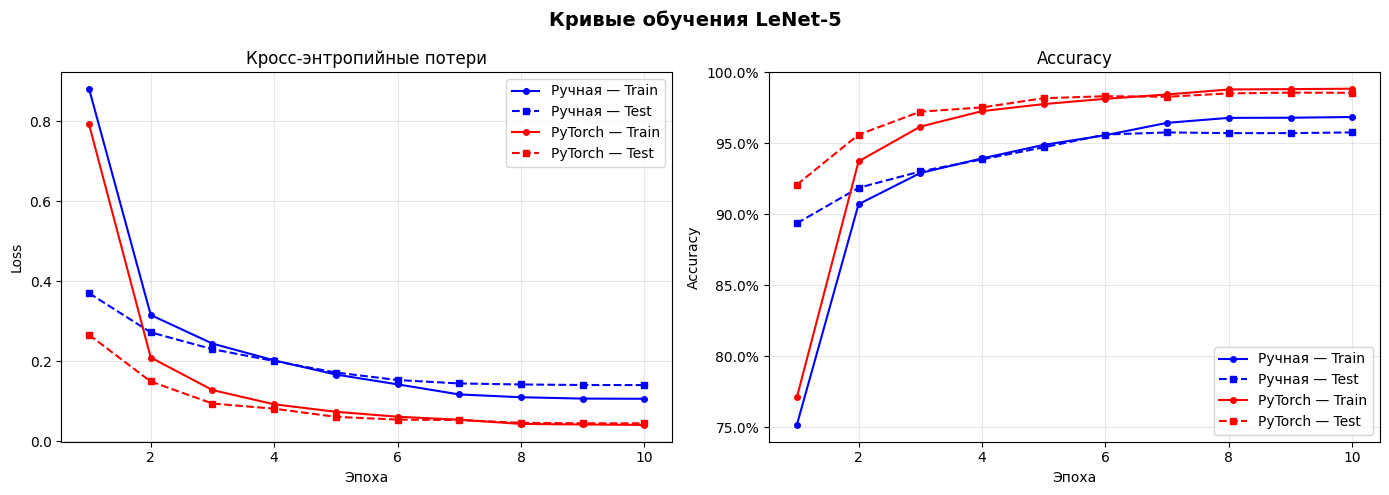

In [9]:
# Кривые обучения
ep_m = range(1, MANUAL_EPOCHS + 1)
ep_t = range(1, TORCH_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Кривые обучения LeNet-5', fontsize=14, fontweight='bold')

ax1.plot(ep_m, hist_m['train_loss'], 'b-o',  ms=4, label='Ручная — Train')
ax1.plot(ep_m, hist_m['test_loss'],  'b--s', ms=4, label='Ручная — Test')
ax1.plot(ep_t, hist_t['train_loss'], 'r-o',  ms=4, label='PyTorch — Train')
ax1.plot(ep_t, hist_t['test_loss'],  'r--s', ms=4, label='PyTorch — Test')
ax1.set_title('Кросс-энтропийные потери')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep_m, hist_m['train_acc'], 'b-o',  ms=4, label='Ручная — Train')
ax2.plot(ep_m, hist_m['test_acc'],  'b--s', ms=4, label='Ручная — Test')
ax2.plot(ep_t, hist_t['train_acc'], 'r-o',  ms=4, label='PyTorch — Train')
ax2.plot(ep_t, hist_t['test_acc'],  'r--s', ms=4, label='PyTorch — Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

In [10]:
# Финальные предсказания и метрики

m_preds = np.concatenate([
    manual_model.predict(X_te[i:i+MANUAL_BATCH])
    for i in range(0, len(X_te), MANUAL_BATCH)
])
m_prec, m_rec, m_f1, m_cm = calc_metrics(y_te, m_preds)
m_acc = calc_accuracy(y_te, m_preds)

torch_model.eval()
t_preds = np.concatenate([
    torch_model(xb.to(DEVICE)).argmax(1).cpu().numpy()
    for xb, _ in test_loader
])
t_prec, t_rec, t_f1, t_cm = calc_metrics(y_test, t_preds)
t_acc = calc_accuracy(y_test, t_preds)

print('+-----------------------+------------------+------------------+')
print('| Метрика               |  Ручная (NumPy)  |     PyTorch      |')
print('+-----------------------+------------------+------------------+')
print(f'| Тренировочных         | {MANUAL_TRAIN_N:>16,} | {len(X_train):>16,} |')
print(f'| Тестовых              | {MANUAL_TEST_N:>16,} | {len(X_test):>16,} |')
print(f'| Accuracy              | {m_acc:>16.4f} | {t_acc:>16.4f} |')
print(f'| Macro Precision       | {m_prec.mean():>16.4f} | {t_prec.mean():>16.4f} |')
print(f'| Macro Recall          | {m_rec.mean():>16.4f} | {t_rec.mean():>16.4f} |')
print(f'| Macro F1              | {m_f1.mean():>16.4f} | {t_f1.mean():>16.4f} |')
print(f'| Время обучения        | {manual_time:>14.1f}s | {torch_time:>14.1f}s |')
print('+-----------------------+------------------+------------------+')

print()
print(f'  {"Класс":>5} | {"Ручная":>28} | {"PyTorch":>28}')
print(f'  {"":>5} | {"Prec":>8} {"Rec":>8} {"F1":>8} | {"Prec":>8} {"Rec":>8} {"F1":>8}')
print('  ' + '-' * 68)
for c in range(10):
    print(f'  {c:>5} | {m_prec[c]:>8.4f} {m_rec[c]:>8.4f} {m_f1[c]:>8.4f} | '
          f'{t_prec[c]:>8.4f} {t_rec[c]:>8.4f} {t_f1[c]:>8.4f}')
print('  ' + '-' * 68)
print(f'  {"macro":>5} | {m_prec.mean():>8.4f} {m_rec.mean():>8.4f} {m_f1.mean():>8.4f} | '
      f'{t_prec.mean():>8.4f} {t_rec.mean():>8.4f} {t_f1.mean():>8.4f}')

+-----------------------+------------------+------------------+
| Метрика               |  Ручная (NumPy)  |     PyTorch      |
+-----------------------+------------------+------------------+
| Тренировочных         |           10,000 |           60,000 |
| Тестовых              |            2,000 |           10,000 |
| Accuracy              |           0.9575 |           0.9854 |
| Macro Precision       |           0.9577 |           0.9854 |
| Macro Recall          |           0.9578 |           0.9853 |
| Macro F1              |           0.9575 |           0.9853 |
| Время обучения        |           96.6s |           19.2s |
+-----------------------+------------------+------------------+

  Класс |                       Ручная |                      PyTorch
        |     Prec      Rec       F1 |     Prec      Rec       F1
  --------------------------------------------------------------------
      0 |   0.9541   0.9842   0.9689 |   0.9848   0.9918   0.9883
      1 |   1.0000   0.9

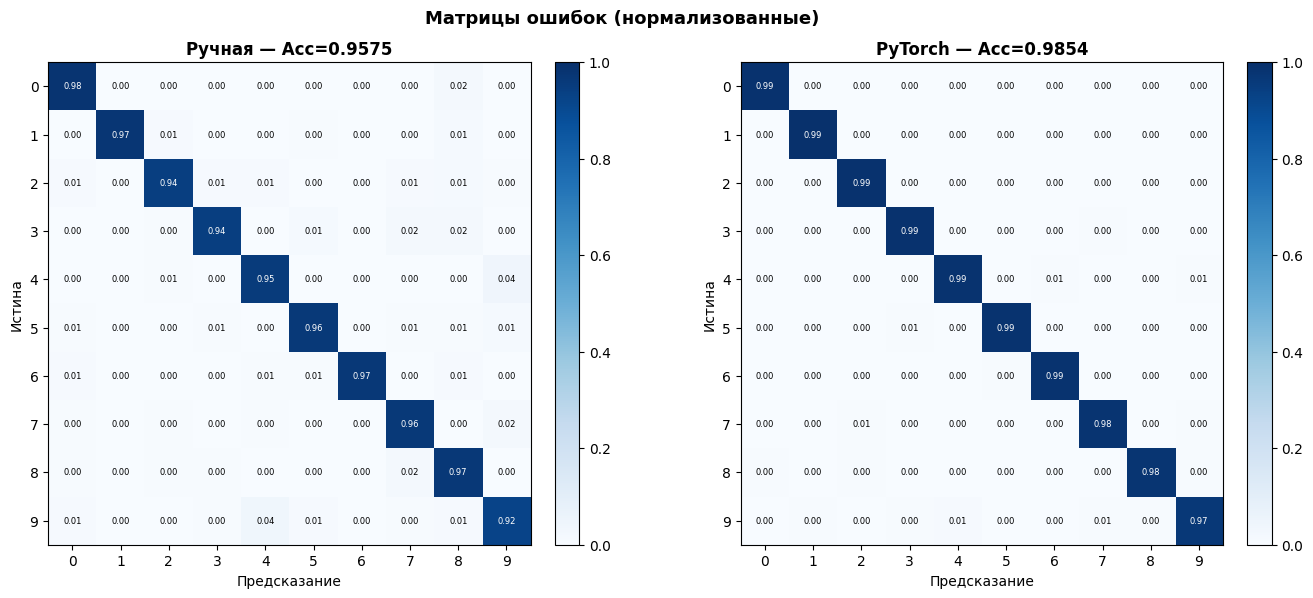

In [11]:
# Матрицы ошибок

def plot_cm(cm, title, ax):
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Предсказание'); ax.set_ylabel('Истина')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, f'{norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if norm[i,j] > 0.5 else 'black')
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Матрицы ошибок (нормализованные)', fontsize=13, fontweight='bold')
im1 = plot_cm(m_cm, f'Ручная — Acc={m_acc:.4f}', ax1)
im2 = plot_cm(t_cm, f'PyTorch — Acc={t_acc:.4f}', ax2)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

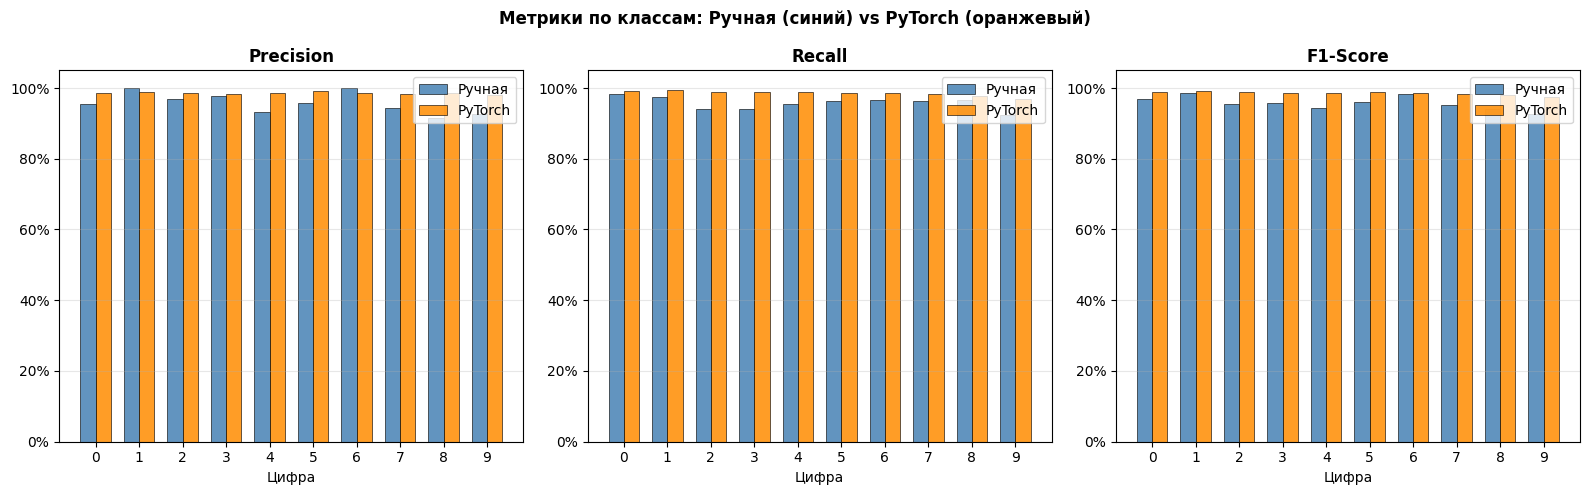

In [12]:
# Precision / Recall / F1 по классам

x = np.arange(10)
w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Метрики по классам: Ручная (синий) vs PyTorch (оранжевый)', fontsize=12, fontweight='bold')

for ax, mv, tv, title in [
    (axes[0], m_prec, t_prec, 'Precision'),
    (axes[1], m_rec,  t_rec,  'Recall'),
    (axes[2], m_f1,   t_f1,   'F1-Score'),
]:
    ax.bar(x - w/2, mv, w, label='Ручная', color='steelblue',  alpha=0.85, edgecolor='k', lw=0.5)
    ax.bar(x + w/2, tv, w, label='PyTorch', color='darkorange', alpha=0.85, edgecolor='k', lw=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Цифра')
    ax.set_xticks(x); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

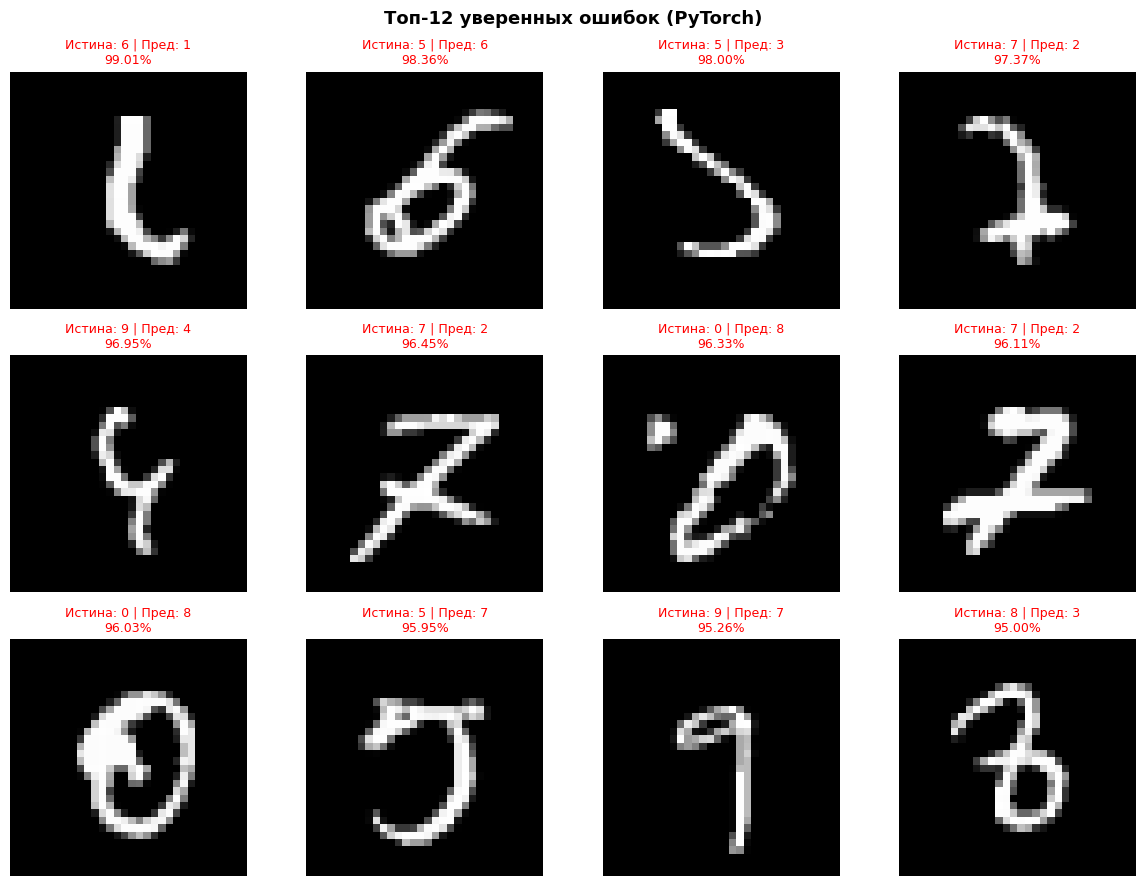

In [13]:
# Топ-12 уверенных ошибок PyTorch

torch_model.eval()
all_probs = np.concatenate([
    torch.softmax(torch_model(xb.to(DEVICE)), 1).detach().cpu().numpy()
    for xb, _ in test_loader
])
wrong = np.where(t_preds != y_test)[0]
conf  = all_probs[wrong, t_preds[wrong]]
top12 = wrong[np.argsort(conf)[::-1][:12]]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Топ-12 уверенных ошибок (PyTorch)', fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flat, top12):
    ax.imshow(X_test[idx, 0], cmap='gray')
    ax.set_title(f'Истина: {y_test[idx]} | Пред: {t_preds[idx]}\n{all_probs[idx, t_preds[idx]]:.2%}',
                 fontsize=9, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

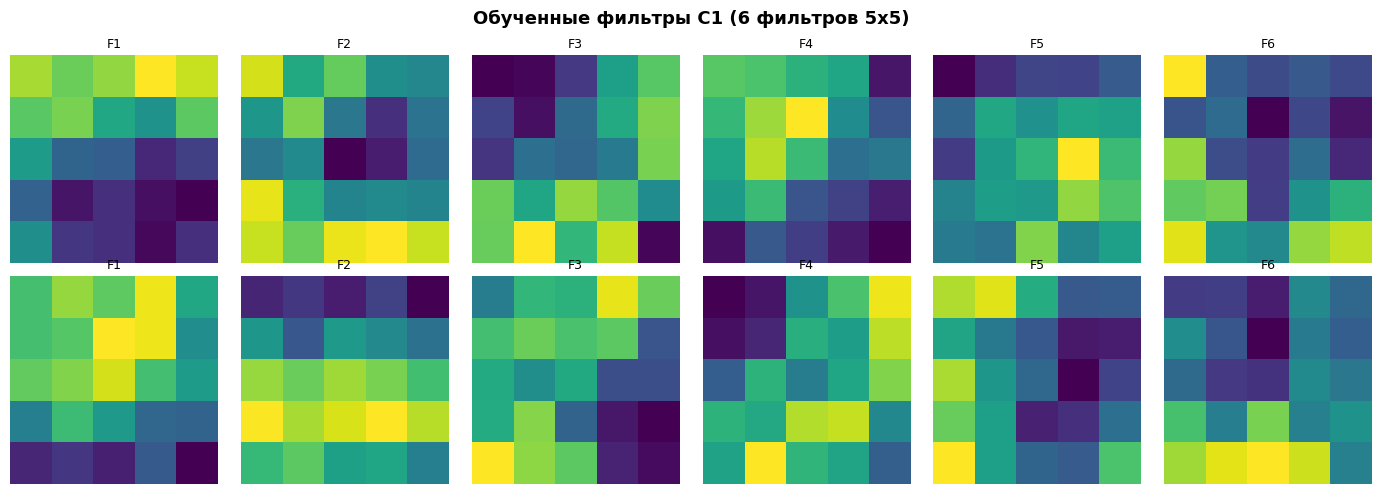

ИТОГ
Ручная   (10,000 обр.) -> Acc=0.9575 | F1=0.9575 | 96.6s
PyTorch  (60,000 обр.) -> Acc=0.9854 | F1=0.9853 | 19.2s
Ускорение PyTorch: ~5.0x


In [14]:
# Веса первого свёрточного слоя C1

def norm01(w):
    return (w - w.min()) / (w.max() - w.min() + 1e-8)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Обученные фильтры C1 (6 фильтров 5x5)', fontsize=13, fontweight='bold')
tw = torch_model.features[0].weight.detach().cpu().numpy()

for i in range(6):
    axes[0, i].imshow(norm01(manual_model.c1.W[i, 0]), cmap='viridis')
    axes[0, i].set_title(f'F{i+1}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(norm01(tw[i, 0]), cmap='viridis')
    axes[1, i].set_title(f'F{i+1}', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Ручная', fontsize=9)
axes[1, 0].set_ylabel('PyTorch', fontsize=9)
plt.tight_layout()
plt.show()

print('=' * 60)
print('ИТОГ')
print('=' * 60)
print(f'Ручная   ({MANUAL_TRAIN_N:,} обр.) -> Acc={m_acc:.4f} | F1={m_f1.mean():.4f} | {manual_time:.1f}s')
print(f'PyTorch  ({len(X_train):,} обр.) -> Acc={t_acc:.4f} | F1={t_f1.mean():.4f} | {torch_time:.1f}s')
if torch_time > 0:
    print(f'Ускорение PyTorch: ~{manual_time/torch_time:.1f}x')